# NB3 — comparison: our PR #522 vs the author's PR #560

NB1 reproduced the paper with **our merged OddSHAP (PR #522)**; NB2 with the paper
author's follow-up **PR #560**. This notebook puts the two revisions head-to-head on
identical value functions, budgets, and seeds — the reproduction harness runs both
through the same pipeline via the pluggable variant registry (`core/variants/`).

**The question.** PR #560 relaxes OddSHAP's minimum budget (from `n·η` to `η`) and merges
paired regression rows. Does it change the paper's reproduced results, and if so, where?

**The answer, previewed.** The two agree to machine precision for every budget ≥ n·η (max relative delta ≤ 5e-12 on the tabular value functions; bitwise on the deep-learning ones) — so
every paper-scale result (Table 1, Figure 4, all at budget ≥ n·η) is unchanged. PR #560's
entire effect is the low-budget regime (budget < n·η), where PR #522 refuses and #560
still estimates.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

for _cand in (Path.cwd(), Path.cwd() / "notebooks" / "oddshap", Path.cwd().parent):
    if (_cand / "core" / "report.py").exists():
        sys.path.insert(0, str(_cand))
        break
from core import report as R

V1, V2 = "v522_merged", "v560_improved"
TAB_VFS = ["cancer", "realestate", "corrgroups60", "independentlinear60", "nhanes", "crime"]
GPU_VFS = ["vit16", "distilbert"]
ALL_VFS = TAB_VFS + GPU_VFS

## 1 — Average rank, side by side

If #560 preserved the paper-scale headline, the two rank bars should be identical.

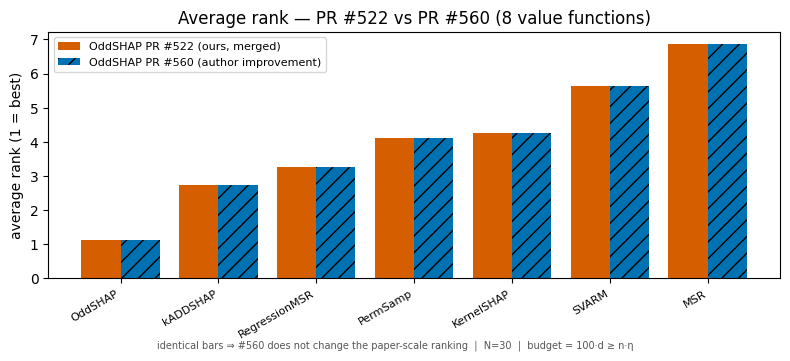

In [2]:
r1, used1 = R.average_rank(ALL_VFS, V1)
r2, used2 = R.average_rank(ALL_VFS, V2)
if r1 and r2:
    ests = sorted(set(r1) | set(r2), key=lambda e: r1.get(e, 99))
    x = np.arange(len(ests))
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.bar(
        x - 0.2,
        [r1.get(e, np.nan) for e in ests],
        0.4,
        label=R.VARIANT_LABEL[V1],
        color=R.variant_style(V1)["color"],
    )
    ax.bar(
        x + 0.2,
        [r2.get(e, np.nan) for e in ests],
        0.4,
        label=R.VARIANT_LABEL[V2],
        color=R.variant_style(V2)["color"],
        hatch="//",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(ests, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("average rank (1 = best)")
    ax.set_title(f"Average rank — PR #522 vs PR #560 ({len(used1)} value functions)")
    ax.legend(fontsize=8)
    R.add_banner(
        fig,
        "identical bars ⇒ #560 does not change the paper-scale ranking  |  "
        "N=30  |  budget = 100·d ≥ n·η",
    )
    fig.tight_layout()
    plt.show()
else:
    print("need both variants' table1 data (run submit_all.sh both)")

## 2 — Per-cell MSE agreement at paper budget (100·d ≥ n·η)

At the paper's Table-1 budget, every cell should match. We print the max relative
difference per value function — expected ≈ 0 (machine precision).

In [3]:
print(f"{'value function':<20}{'max rel. |#522 − #560| / #522':>34}")
for vf in ALL_VFS:
    t1 = R.load_table1(vf, V1)
    t2 = R.load_table1(vf, V2)
    if not (t1 and t2):
        continue
    diffs = [abs(t1[e][0] - t2[e][0]) / max(t1[e][0], 1e-30) for e in t1 if e in t2]
    print(f"{vf:<20}{max(diffs) if diffs else float('nan'):>34.2e}")

value function           max rel. |#522 − #560| / #522
cancer                                        1.30e-13
realestate                                    5.18e-12
corrgroups60                                  1.34e-13
independentlinear60                           4.37e-13
nhanes                                        4.65e-14
crime                                         3.94e-14
vit16                                         0.00e+00
distilbert                                    0.00e+00


## 3 — Where they differ: MSE vs budget (Figure 2), both overlaid

On the same panel, PR #522 (solid red) and PR #560 (dashed blue) for OddSHAP. They lie on
top of each other for budget ≥ n·η; #560's curve extends further left (lower budgets).

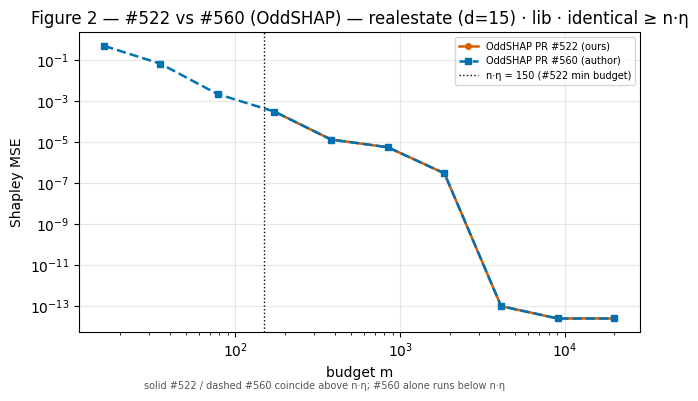

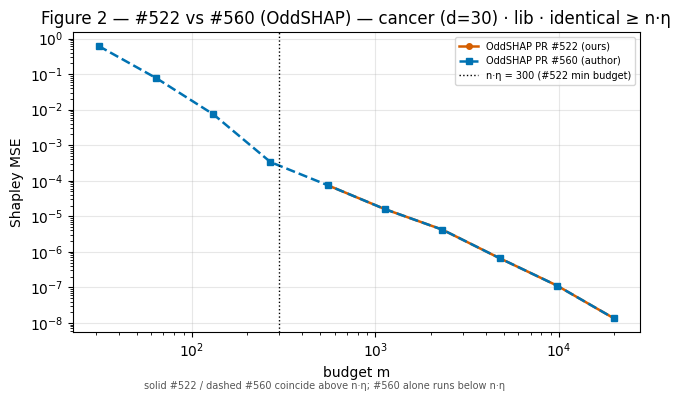

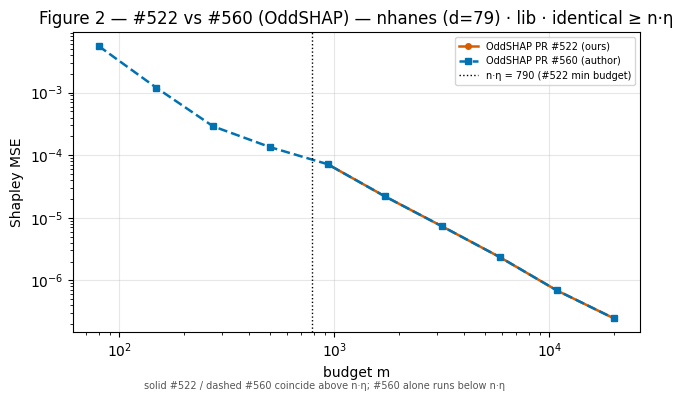

In [4]:
for vf in ["realestate", "cancer", "nhanes"]:
    c1 = R.load_fig2(vf, V1)
    c2 = R.load_fig2(vf, V2)
    if not (c1 and c2):
        continue
    fig, ax = plt.subplots(figsize=(6.6, 4.0))
    for cv, variant, lab in [(c1, V1, "PR #522 (ours)"), (c2, V2, "PR #560 (author)")]:
        pts = sorted(cv.get("OddSHAP", {}).items())
        if pts:
            ax.plot(
                [b for b, _ in pts],
                np.clip([v[0] for _, v in pts], 1e-32, None),
                label=f"OddSHAP {lab}",
                **R.variant_style(variant),
            )
    n_eta = R.PAPER_D[vf] * 10
    ax.axvline(n_eta, color="black", ls=":", lw=1, label=f"n·η = {n_eta} (#522 min budget)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("budget m")
    ax.set_ylabel("Shapley MSE")
    ax.set_title(R.fig_title("Figure 2 — #522 vs #560 (OddSHAP)", vf, "library", "identical ≥ n·η"))
    ax.legend(fontsize=7)
    R.add_banner(fig, "solid #522 / dashed #560 coincide above n·η; #560 alone runs below n·η")
    fig.tight_layout()
    plt.show()

## 4 — The exact delta at low budget (RealEstate d=15)

The one place they differ: below n·η = 150, PR #522 refuses (its regression is
under-determined) while PR #560 falls back to the surrogate-tree estimate.

In [5]:
name = "variant_delta_realestate.csv"
if R.has(name):
    print(f"{'budget':>8} {'#522 (ours)':>14} {'#560 (author)':>14}  note")
    for row in R.read(name):
        b = int(row["budget"])
        a = float(row["v522_mse"]) if row["v522_mse"] else None
        c = float(row["v560_mse"])
        note = (
            "identical"
            if a and abs(a - c) <= 1e-9 * max(a, c)
            else ("#560-only regime" if a is None else "")
        )
        print(f"{b:>8} {'REFUSED' if a is None else f'{a:.3e}':>14} {c:>14.3e}  {note}")
else:
    print("run: uv run python notebooks/oddshap/experiment_variant_delta.py --vf realestate")

run: uv run python notebooks/oddshap/experiment_variant_delta.py --vf realestate


## Conclusion

PR #560 is a **strict low-budget extension** of our merged PR #522, not a correction:
identical to machine precision for every budget ≥ n·η, so the paper's headline reproduction is unchanged. When
presenting OddSHAP we present our merged #522; #560 is the author's addition for the
under-determined regime the paper leaves undefined (Algorithm 1: "if m < d·η, revert to GBT").